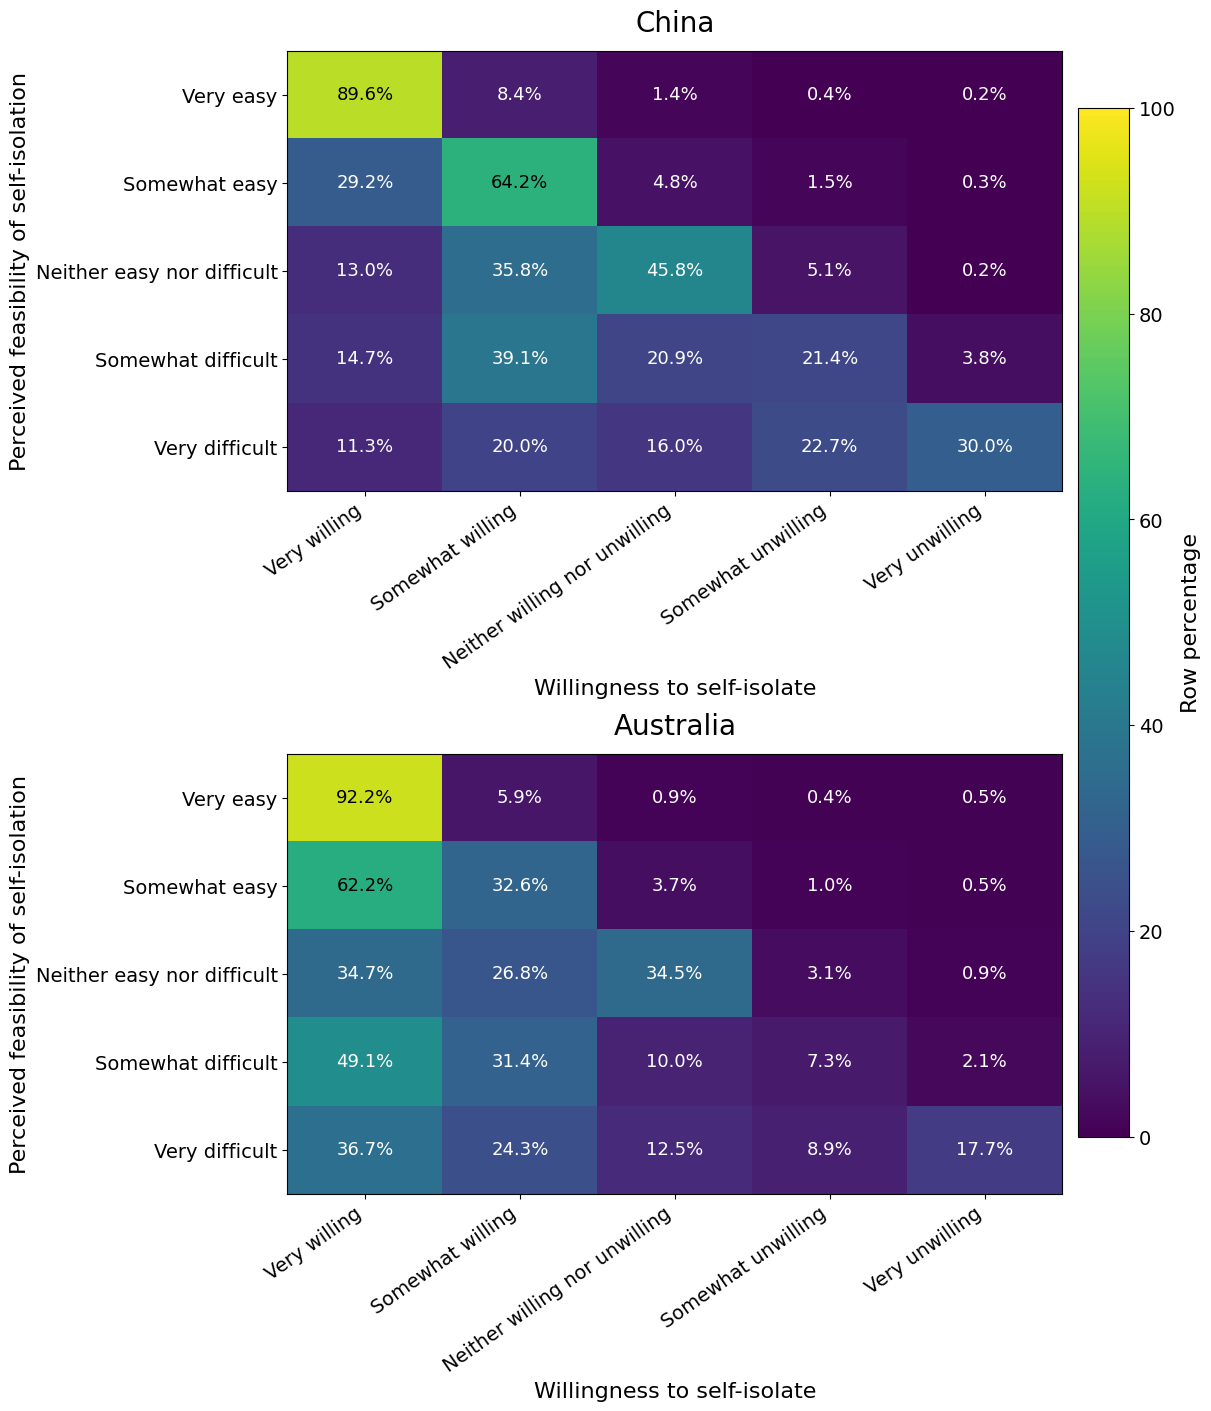

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. read data
use_cols = ["i10_health", "i11_health"]

china_df = pd.read_csv(
    "../data/raw/china.csv",
    usecols=use_cols,
    na_values=[" ", "__NA__"],
    keep_default_na=True,
    low_memory=False
)

australia_df = pd.read_csv(
    "../data/raw/australia.csv",
    usecols=use_cols,
    na_values=[" ", "__NA__"],
    keep_default_na=True,
    low_memory=False
)


# 2. Define variables and category orders
feasibility_col = "i10_health"
willingness_col = "i11_health"

feasibility_order = [
    "Very easy",
    "Somewhat easy",
    "Neither easy nor difficult",
    "Somewhat difficult",
    "Very difficult"
]

willingness_order = [
    "Very willing",
    "Somewhat willing",
    "Neither willing nor unwilling",
    "Somewhat unwilling",
    "Very unwilling"
]


# 3. Create row percentage crosstab
def create_row_percent_crosstab(df):
    # keep only i10 and i11
    temp_df = df[[feasibility_col, willingness_col]].copy()

    # remove missing values and Not sure responses
    temp_df = temp_df.dropna(subset=[feasibility_col, willingness_col])
    temp_df = temp_df[
        (temp_df[feasibility_col] != "Not sure")
        & (temp_df[willingness_col] != "Not sure")
    ]

    # create crosstab
    counts = pd.crosstab(
        temp_df[feasibility_col],
        temp_df[willingness_col]
    )

    # reorder rows and columns
    counts = counts.reindex(
        index=feasibility_order,
        columns=willingness_order,
        fill_value=0
    )

    # convert to row percentage
    row_percent = counts.div(counts.sum(axis=1), axis=0) * 100

    return row_percent


china_percent = create_row_percent_crosstab(china_df)
australia_percent = create_row_percent_crosstab(australia_df)


# 4. Plot heatmap function
def plot_heatmap(ax, data, title):
    im = ax.imshow(
        data.values,
        cmap="viridis",
        vmin=0,
        vmax=100,
        aspect="auto"
    )

    ax.set_title(title, fontsize=20, pad=14)

    ax.set_xticks(np.arange(len(willingness_order)))
    ax.set_yticks(np.arange(len(feasibility_order)))

    ax.set_xticklabels(
        willingness_order,
        fontsize=14,
        rotation=35,
        ha="right"
    )
    ax.set_yticklabels(feasibility_order, fontsize=14)

    ax.set_xlabel("Willingness to self-isolate", fontsize=16)
    ax.set_ylabel("Perceived feasibility of self-isolation", fontsize=16)

    # add percentage labels inside cells
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            value = data.iloc[i, j]
            text_color = "white" if value < 50 else "black"

            ax.text(
                j,
                i,
                f"{value:.1f}%",
                ha="center",
                va="center",
                color=text_color,
                fontsize=13
            )

    return im


# 5. Plot China and Australia
fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 14),
    constrained_layout=True
)

im1 = plot_heatmap(axes[0], china_percent, "China")
im2 = plot_heatmap(axes[1], australia_percent, "Australia")

# Shared colorbar
cbar = fig.colorbar(
    im2,
    ax=axes,
    shrink=0.9,
    pad=0.02
)

cbar.set_label("Row percentage", fontsize=16)
cbar.ax.tick_params(labelsize=14)

plt.savefig(
    "../results/figures/china_australia_feasibility_willingness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()